<center>
    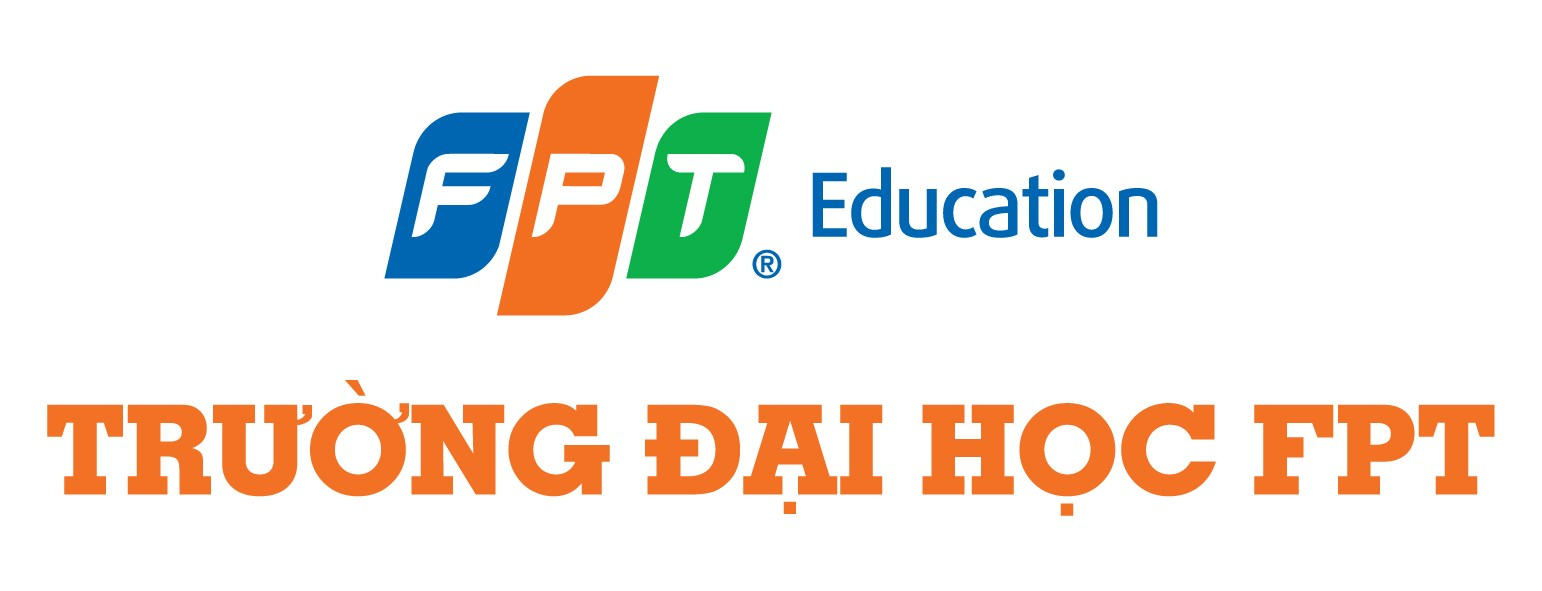
    
# Reinforcement Learning 
# Lab 1: Frozen Lake 
</center>



<br>

#### Class name: AI1902-AA

#### Student code: HE195216

#### Student name: Duong Ngoc Anh

<br>

<a alt='AI1902'></a>
## Objectives
You will use the knowledge you have learned and implement one of the reinforcement learning algorithms yourself to solve the frozen lake problem. Note that the reinforcement learning algorithms are unlimited, you can choose any algorithm that you feel good to implement.

After completing this assignment you will be able to:

*   Describe the concept of reinforcement learning include agent, environment, action, reward ...
*   Understand about one of the RL optimization methods
*   Implement one of the reinforcement learing algorithms

Estimated time needed: **90** minutes
<h3 style='color:red;'>Note: After submitting the assignment, students will have to answer oral questions to demonstrate their understanding of the implemented algorithm.
</h5>

## 1. Introduction
<center><img src='img/frozen_lake.gif' width = 300/></center>
This environment is part of the Toy Text environments which contains general information about the environment.

Frozen lake involves crossing a frozen lake from start to goal without falling into any holes by walking over the frozen lake. The player may not always move in the intended direction due to the slippery nature of the frozen lake. 

### Description
The game starts with the player at location [0,0] of the frozen lake grid world with the goal located at far extent of the world e.g. [3,3] for the 4x4 environment.

Holes in the ice are distributed in set locations when using a pre-determined map or in random locations when a random map is generated.

The player makes moves until they reach the goal or fall in a hole.

The lake is slippery (unless disabled) so the player may move perpendicular to the intended direction sometimes (see is_slippery).

Randomly generated worlds will always have a path to the goal.

Elf and stool from https://franuka.itch.io/rpg-snow-tileset. All other assets by Mel Tillery http://www.cyaneus.com/.

### Action Space
The action shape is (1,) in the range {0, 3} indicating which direction to move the player.

- 0: Move left
- 1: Move down
- 2: Move right
- 3: Move up

### Observation Space
The observation is a value representing the player’s current position as current_row * nrows + current_col (where both the row and col start at 0).

For example, the goal position in the 6x6 map can be calculated as follows: 5 * 6 + 5 = 35. The number of possible observations is dependent on the size of the map.

The observation is returned as an int().

### Starting State
The episode starts with the player in state [0] (location [0, 0]).

Rewards
Reward schedule:

- Reach goal: +1
- Reach hole: 0
- Reach frozen: 0

### Episode End
The episode ends if the following happens:

- Termination:

    1. The player moves into a hole.

    2. The player reaches the goal at max(nrow) * max(ncol) - 1 (location [max(nrow)-1, max(ncol)-1]).

- Truncation (when using the time_limit wrapper):

    1. The length of the episode is 100 for 4x4 environment, 200 for FrozenLake8x8-v1 environment.

### Information
step() and reset() return a dict with the following keys:

p - transition probability for the state.

See is_slippery for transition probability information.

### Arguments
```python
import gymnasium as gym
gym.make('FrozenLake-v1', desc=None, map_name="4x4", is_slippery=True)
desc=None: Used to specify maps non-preloaded maps.
```
Specify a custom map.

```python
desc = [
        "SFFHFF",
        "FFFFFF",
        "FHFFHH",
        "FFHFFF",
        "HFFFFH",
        "FFHFFG",
    ]
gym.make('FrozenLake-v1', desc=desc)
```
If `desc=None` then `map_name` will be used. If both desc and map_name are None a random 8x8 map with 80% of locations frozen will be generated.

`is_slippery=True`: If true the player will move in intended direction with probability of 1/3 else will move in either perpendicular direction with equal probability of 1/3 in both directions.

For example, if action is left and is_slippery is True, then:

- P(move left)=1/3
- P(move up)=1/3
- P(move down)=1/3

### Results
After optimization with `is_slippery=False`, use `plot_policy` function to draw the policy to visual policy and evaluate the learned policy. 

**Note that:**
<div style="display:block;"><img src='img/termial.jpg' width = 40/> is the terminal state and the state value at terminal state should be [0, 0, 0, 0]</div>

<div style="display:block;"><img src='img/state_policy.jpg' width = 40/> is the policy of normal state, and agent will choose down or right to do the action. The state value should be [0, 0.5, 0.5, 0]</div>



Try yourself to find out what's optimal policy if  `is_slippery=True`

In [30]:
#!pip install gym
#!pip install gymnasium[toy_text]

In [31]:
import numpy as np
import gymnasium as gym
from plot_utils import plot_policy


In [32]:
world_size = [6, 6]
desc=[
    "SFFHFF",
    "FFFFFF",
    "FHFFHH",
    "FFHFFF",
    "HFFFFH",
    "FFHFFG",
]

In [33]:
env=gym.make('FrozenLake-v1', desc=desc, render_mode="human", is_slippery=False)

start = env.reset()
print('Initial state of the system', start)
sample_step = 10
for i in range(sample_step):
    action  = env.action_space.sample()
    observation, reward, terminated, truncated, info = env.step(action)
    if(terminated or truncated):
        start = env.reset()

env.render()
env.close()

Initial state of the system (0, {'prob': 1})


In [34]:
# START YOUR CODE HERE 
# Define the action space and state space

# In gymnasium, the observation space represents all possible states the agent can be in.
# For a 6x6 Frozen Lake, this is a Discrete space of size 36 (0 to 35).
num_states = env.observation_space.n

# The action space represents the possible moves the agent can make.
# In Frozen Lake, there are 4 actions: 0 (Left), 1 (Down), 2 (Right), 3 (Up).
num_actions = env.action_space.n

print("State space size (number of possible states):", num_states)
print("Action space size (number of possible actions):", num_actions)


State space size (number of possible states): 36
Action space size (number of possible actions): 4


In [35]:
class Agent:
    def __init__(self, grid_size):
        # We define the number of possible actions (Left, Down, Right, Up)
        self.num_actions = 4  
        # The discount factor gamma represents how much we care about future rewards compared to immediate ones
        self.gamma = 0.99
        # Initialize a policy table of size (num_states, num_actions) with all zeros
        self.policy = np.zeros((env.observation_space.n, self.num_actions))
        # Define the terminal states in our 6x6 grid. These are the holes and the goal.
        # Entering any of these states terminates the episode.
        self.terminals = [3, 13, 16, 17, 20, 24, 29, 32, 35]
        
    def value_iteration(self, env, theta=1e-8):
        """
        Runs the Value Iteration algorithm to find the optimal state-value function V*.
        
        Parameters:
        - env: The gymnasium environment instance.
        - theta: The convergence threshold. Iterations stop when the maximum change in value
                 across all states is less than theta.
        """
        num_states = env.observation_space.n
        # Initialize the state-value function V to all zeros
        V = np.zeros(num_states)
        
        while True:
            delta = 0  # Track the maximum change in state values during this sweep
            for state in range(num_states):
                # If the state is a terminal state, its value remains 0 (no future rewards)
                if state in self.terminals:
                    continue
                
                v = V[state]
                action_values = np.zeros(self.num_actions)
                
                # Calculate the expected value of taking each action from the current state
                for action in range(self.num_actions):
                    # env.unwrapped.P[state][action] gives a list of transition tuples:
                    # (probability, next_state, reward, done)
                    transitions = env.unwrapped.P[state][action]
                    for prob, next_state, reward, done in transitions:
                        # Bellman Expectation equation for action-value:
                        # sum_{s'} P(s' | s, a) * [ R(s, a, s') + gamma * V(s') ]
                        action_values[action] += prob * (reward + self.gamma * V[next_state])
                
                # Update the value function with the maximum expected action value (Bellman Optimality update)
                V[state] = np.max(action_values)
                
                # Update the maximum change
                delta = max(delta, abs(v - V[state]))
            
            # Stop iterating if the value function has converged
            if delta < theta:
                break
                
        return V
        
    def update_policy(self, value_function):
        """
        Derives the optimal greedy policy based on the computed optimal value function V*.
        
        Parameters:
        - value_function: The optimal state-value function V*.
        """
        for state in range(env.observation_space.n):
            # For terminal states, set a uniform policy of [0.0, 0.0, 0.0, 0.0] 
            # to match the template requirements (drawing a circle).
            if state in self.terminals:
                self.policy[state] = [0.0, 0.0, 0.0, 0.0]
            else:
                action_values = np.zeros(self.num_actions)
                
                # Calculate expected values for all possible actions
                for action in range(self.num_actions):
                    transitions = env.unwrapped.P[state][action]
                    for prob, next_state, reward, done in transitions:
                        action_values[action] += prob * (reward + self.gamma * value_function[next_state])
                
                # To handle cases where multiple actions achieve the maximum value,
                # we find all actions that are equal to the maximum and distribute 
                # probability equally among them.
                best_action_value = np.max(action_values)
                best_actions = np.where(np.isclose(action_values, best_action_value))[0]
                
                self.policy[state] = np.zeros(self.num_actions)
                for a in best_actions:
                    self.policy[state][a] = 1.0 / len(best_actions)
        
        return self.policy


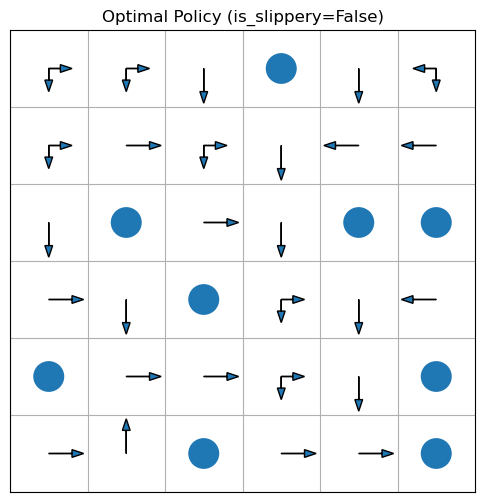

In [36]:
### DRAW POLICY WITH is_slippery=False ###

# 1. Initialize the Agent for a 6x6 grid
agent = Agent((6,6))

# 2. Run Value Iteration to compute the optimal state-value function V*
# Under is_slippery=False, the environment is completely deterministic.
V_opt = agent.value_iteration(env)

# 3. Update and derive the optimal policy from V*
agent.policy = agent.update_policy(V_opt)

# Define action mapping arrows for visualization:
# 0: Left -> (-1, 0), 1: Down -> (0, -1), 2: Right -> (1, 0), 3: Up -> (0, 1)
arrows = {"0":(-1,0), "1":(0,-1), "2":(1,0), "3":(0,1)}

# Reshape policy to (6, 6, 4) for the plotting utility
policy = np.array(agent.policy).reshape((6,6,4))

# Plot the optimal policy for deterministic environment
plot_policy(policy, arrows, label='Optimal Policy (is_slippery=False)')


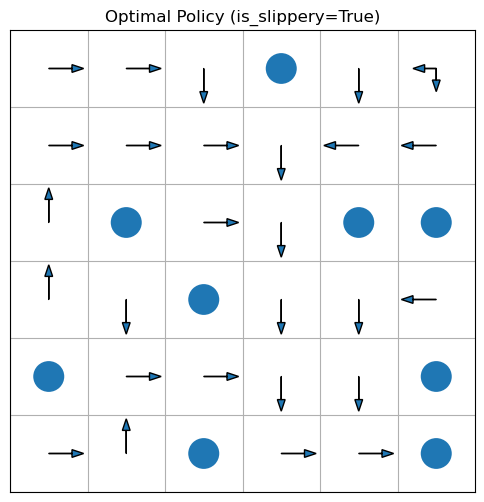

In [37]:
### TRY TO FIND AND DRAW POLICY WITH is_slippery=True FOR YOURSELF ###

# 1. Create a stochastic environment by setting is_slippery=True.
# When slippery is True, the agent only moves in the intended direction with 1/3 probability,
# and with 1/3 probability in either perpendicular direction.
env_slippery = gym.make('FrozenLake-v1', desc=desc, render_mode="human", is_slippery=True)

# 2. Initialize a new Agent instance
agent_slippery = Agent((6,6))

# 3. Run Value Iteration on the stochastic environment
V_opt_slippery = agent_slippery.value_iteration(env_slippery)

# 4. Derive the optimal policy for the stochastic setting
agent_slippery.policy = agent_slippery.update_policy(V_opt_slippery)

# 5. Define arrows and plot the stochastic policy
arrows = {"0":(-1,0), "1":(0,-1), "2":(1,0), "3":(0,1)}
policy_slippery = np.array(agent_slippery.policy).reshape((6,6,4))
plot_policy(policy_slippery, arrows, label='Optimal Policy (is_slippery=True)')

# 6. Properly close the environment
env_slippery.close()


In [38]:
env.close()